<div style="border-bottom: 2px solid #B30033; padding-bottom: 15px; margin-bottom: 20px;">
  <h1><span style="color: #B30033;">CARDIS</span> — Hito 3 · Persona B</h1>
  <h2>Sección 3.4.4: Explicabilidad (SHAP)</h2>
  <h2>Sección 3.5: Discusión</h2>
  <h2>Sección 3.6: Conclusiones y trabajo futuro</h2>
  <p style="color: #888;">DISIA — Máster en Inteligencia Artificial — UCLM · Grupo 6 · Marzo 2026</p>
</div>

> **Instrucciones de uso:**  
> Este notebook asume que la Persona A ha completado su trabajo y ha depositado en el repositorio:  
> - `models/cardis_model_final.joblib` — pipeline completo (preprocesamiento + modelo)  
> - `data/processed/cardio_risk_train_fe.csv` — dataset de entrenamiento con feature engineering  
> - `data/processed/predicciones_cv.csv` — predicciones y probabilidades por fold de CV  
> - `data/processed/tabla_resultados.csv` — tabla comparativa de métricas de todos los modelos

## Índice

- [0. Configuración del entorno](#0)
- [1. Carga del modelo y los datos](#1)
- [2. Cálculo de SHAP values](#2)
- [3.4.4 Análisis de Explicabilidad SHAP](#344)
  - [3.4.4.A Summary plot (importancia global)](#344a)
  - [3.4.4.B Waterfall plots: análisis de casos individuales](#344b)
  - [3.4.4.C Dependence plots: relaciones no lineales](#344c)
  - [3.4.4.D Coherencia clínica: validación de las explicaciones](#344d)
- [3.5 Discusión](#35)
- [3.6 Conclusiones y trabajo futuro](#36)

<a id="0"></a>
---
## 0. Configuración del entorno

In [1]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, brier_score_loss
)
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

# ── Estilo global de figuras ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
CARDIS_RED   = '#B30033'
CARDIS_BLUE  = '#1A5276'
CARDIS_GREEN = '#1E8449'
SEED = 42
np.random.seed(SEED)

print(f"SHAP version : {shap.__version__}")
print("Entorno configurado correctamente.")

c:\Users\alonc\Desktop\DISIA_Grupo6\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version : 0.51.0
Entorno configurado correctamente.


<a id="1"></a>
---
## 1. Carga del modelo y los datos

In [2]:
# ── Target Encoder (replicado de cardis_pipeline.ipynb) ────────────────────────
# Sustituye cada categoría por la media suavizada del target en esa categoría.
# El smoothing evita sobreajuste en categorías con pocas observaciones.
class TargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns, smoothing=1.0):
        self.columns = columns
        self.smoothing = smoothing
        self.mapping_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = X.copy()
        self.global_mean_ = y.mean()
        for col in self.columns:
            if col in X.columns:
                stats = y.groupby(X[col]).agg(['mean', 'count'])
                # Fórmula de suavizado: pondera entre la media de la categoría
                # y la media global según el nº de observaciones
                smooth = (
                    (stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
                    / (stats['count'] + self.smoothing)
                )
                self.mapping_[col] = smooth.to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            if col in X.columns:
                # Categorías no vistas en fit se rellenan con la media global
                X[col] = X[col].map(self.mapping_.get(col, {})).fillna(self.global_mean_)
        return X


In [3]:
# ── 1.A  Cargar modelo final (pipeline completo de Persona A) ──────────────────
MODEL_PATH = 'models/cardis_modelo_final.joblib'
loaded = joblib.load(MODEL_PATH)

# El archivo es un dict {'modelo': LGBMClassifier}, no un sklearn Pipeline
modelo_base = loaded['modelo'] if isinstance(loaded, dict) else loaded
model_name  = type(modelo_base).__name__

print(f"Tipo objeto cargado : {type(loaded).__name__}")
print(f"Modelo base         : {model_name}")
if isinstance(loaded, dict):
    print(f"Claves del dict     : {list(loaded.keys())}")
print(f"N.º árboles         : {modelo_base.n_estimators}")
print(f"Features del modelo : {len(modelo_base.feature_name_)}")

Tipo objeto cargado : dict
Modelo base         : LGBMClassifier
Claves del dict     : ['modelo', 'target_encoder', 'imputer', 'threshold', 'feature_names', 'params', 'seed']
N.º árboles         : 450
Features del modelo : 38


In [4]:
# ── 1.B  Cargar datos procesados ───────────────────────────────────────────────
df = pd.read_csv('../data/processed/cardio_risk_train_fe.csv')

X = df.drop(columns=['riesgo_cv'])
y = df['riesgo_cv']

# Partición idéntica a la de Persona A (misma semilla y estrategia)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Las features que espera el modelo (en este orden exacto)
FEATURE_COLS = modelo_base.feature_name_

# Reordenar X para que coincida exactamente con lo que vio el modelo en train
X      = df[FEATURE_COLS]
y      = df['riesgo_cv']

print(f"Dataset cargado : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Train : {X_train.shape[0]:,} | Validación : {X_val.shape[0]:,}")
print(f"Prevalencia alto riesgo (train) : {y_train.mean():.3f}")
print(f"Prevalencia alto riesgo (val)   : {y_val.mean():.3f}")

Dataset cargado : 24,000 filas × 39 columnas
Train : 19,200 | Validación : 4,800
Prevalencia alto riesgo (train) : 0.219
Prevalencia alto riesgo (val)   : 0.219


In [5]:
# ── 1.B.2  Aplicar Target Encoding e imputación (sin RobustScaler) ─────────────
# El modelo fue entrenado con TargetEncoding en hospital_origen y codigo_postal,
# e imputación por mediana. NO se aplicó RobustScaler (LightGBM no lo necesita).

from sklearn.impute import SimpleImputer

COLS_TE = ['hospital_origen', 'codigo_postal']

# Target Encoding: calcular media del target POR CATEGORÍA solo sobre X_train
te_maps = {}
global_mean = y_train.mean()
for col in COLS_TE:
    if col in X_train.columns:
        agg   = pd.concat([X_train[col], y_train], axis=1)
        agg.columns = ['cat', 'target']
        counts = agg['cat'].value_counts()
        means  = agg.groupby('cat')['target'].mean()
        smoothing = 1.0
        smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
        te_maps[col] = smooth.to_dict()

def apply_te(df_in, te_maps, global_mean):
    df_out = df_in.copy()
    for col, mapping in te_maps.items():
        if col in df_out.columns:
            df_out[col] = df_out[col].map(mapping).fillna(global_mean)
    return df_out

X_train_proc = apply_te(X_train, te_maps, global_mean)
X_val_proc   = apply_te(X_val,   te_maps, global_mean)

# Imputación por mediana (solo ajustada sobre train)
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train_proc)

X_train_proc = pd.DataFrame(imputer.transform(X_train_proc), columns=FEATURE_COLS)
X_val_proc   = pd.DataFrame(imputer.transform(X_val_proc),   columns=FEATURE_COLS)

print(f"X_train_proc shape : {X_train_proc.shape}  — NaN restantes: {X_train_proc.isnull().sum().sum()}")
print(f"X_val_proc   shape : {X_val_proc.shape}  — NaN restantes: {X_val_proc.isnull().sum().sum()}")

X_train_proc shape : (19200, 38)  — NaN restantes: 0
X_val_proc   shape : (4800, 38)  — NaN restantes: 0


In [6]:
# ── 1.C  Obtener probabilidades del modelo y verificar rendimiento ─────────────
# Usamos el conjunto de validación para los análisis SHAP (datos no vistos durante el entrenamiento)
y_val_proba = modelo_base.predict_proba(X_val_proc)[:, 1]
y_val_pred  = modelo_base.predict(X_val_proc)

print("Métricas del modelo final en validación:")
print(f"  F1-Score  : {f1_score(y_val, y_val_pred):.4f}")
print(f"  Recall    : {recall_score(y_val, y_val_pred):.4f}")
print(f"  Precision : {precision_score(y_val, y_val_pred):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"  Brier     : {brier_score_loss(y_val, y_val_proba):.4f}")

Métricas del modelo final en validación:
  F1-Score  : 0.8401
  Recall    : 0.9324
  Precision : 0.7644
  AUC-ROC   : 0.9819
  Brier     : 0.0545


<a id="2"></a>
---
## 2. Cálculo de SHAP values

In [7]:
# ── 2.A  El modelo ya está extraído. Solo preparamos el background dataset ─────
# No hay pipeline que desmontar: el modelo es un LGBMClassifier directo.
# X_train_proc y X_val_proc ya contienen los datos en el espacio correcto.

print(f"Modelo base     : {type(modelo_base).__name__}")
print(f"Datos val shape : {X_val_proc.shape}")
print(f"Features match  : {list(X_val_proc.columns) == list(modelo_base.feature_name_)}")

Modelo base     : LGBMClassifier
Datos val shape : (4800, 38)
Features match  : True


In [8]:
# ── 2.B  Instanciar el TreeExplainer y calcular SHAP values ───────────────────
# Para LightGBM/XGBoost/RandomForest: TreeExplainer es exacto y eficiente.
# background: muestra representativa del dataset de entrenamiento (evita costes O(n)).

print("Calculando SHAP values... (puede tardar 1-2 minutos)")

explainer = shap.TreeExplainer(modelo_base)

shap_values = explainer.shap_values(X_val_proc, check_additivity=False)

# Para clasificación binaria, algunos modelos devuelven lista [clase0, clase1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]    # nos quedamos con la clase positiva (alto riesgo)

import scipy.special
raw_ev = explainer.expected_value
if isinstance(raw_ev, (list, np.ndarray)):
    raw_ev = raw_ev[1]
# Convertir de log-odds a probabilidad para que sea coherente con predict_proba
expected_value = float(scipy.special.expit(raw_ev))

print(f"SHAP values calculados.")
print(f"  Shape           : {shap_values.shape}  (filas × features)")
print(f"  Valor esperado  : {expected_value:.4f}  (predicción base del modelo)")
print(f"  Media |SHAP|    : {np.abs(shap_values).mean():.4f}")

Calculando SHAP values... (puede tardar 1-2 minutos)
SHAP values calculados.
  Shape           : (4800, 38)  (filas × features)
  Valor esperado  : 0.0724  (predicción base del modelo)
  Media |SHAP|    : 0.2128


In [9]:
# ── 2.C  Crear el objeto Explanation de SHAP (API moderna) ────────────────────
# Requerido para waterfall plots y otros gráficos de la API nueva de SHAP.
proba_base = float(scipy.special.expit(raw_ev))
shap_values_proba = shap_values * proba_base * (1 - proba_base)

explanation = shap.Explanation(
    values        = shap_values_proba,
    base_values   = np.full(len(shap_values_proba), expected_value),
    data          = X_val_proc.values,
    feature_names = X_val_proc.columns.tolist()
)

# Tabla de importancia global: media del |SHAP| por variable
shap_importance = pd.DataFrame({
    'feature'      : X_val_proc.columns,
    'mean_abs_shap': np.abs(shap_values_proba).mean(axis=0)  # ← cambiar
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 15 variables por importancia SHAP global:")
print(shap_importance.head(15).to_string(index=False))

Top 15 variables por importancia SHAP global:
         feature  mean_abs_shap
   codigo_postal       0.072500
 horas_actividad       0.048794
     presion_std       0.046870
colesterol_total       0.042950
   presion_media       0.038692
            edad       0.034101
  glucosa_ayunas       0.033451
             ldl       0.030537
            hora       0.029468
         fumador       0.017564
      dia_semana       0.017387
 presion_mediana       0.016564
 glucosa_missing       0.014554
  longitud_notas       0.014512
             hdl       0.009568


<a id="344"></a>
---
## 3.4.4 Análisis de Explicabilidad SHAP

Esta sección responde a la **RQ1** (*¿qué modelo ofrece el mejor equilibrio rendimiento–explicabilidad?*)
y a la **RQ2** (*¿cuánto aporta la ingeniería de características clínicas?*), evaluando si las
explicaciones del modelo seleccionado son coherentes con el conocimiento clínico establecido en la
literatura cardiovascular.

<a id="344a"></a>
### 3.4.4.A  Summary plot — Importancia global de variables

El *beeswarm summary plot* representa, para cada variable, la distribución de sus SHAP values sobre
todos los registros del conjunto de validación. Cada punto es un paciente; el color indica el valor de
la variable (rojo = alto, azul = bajo); la posición horizontal indica la dirección e intensidad del efecto
sobre la predicción de alto riesgo.

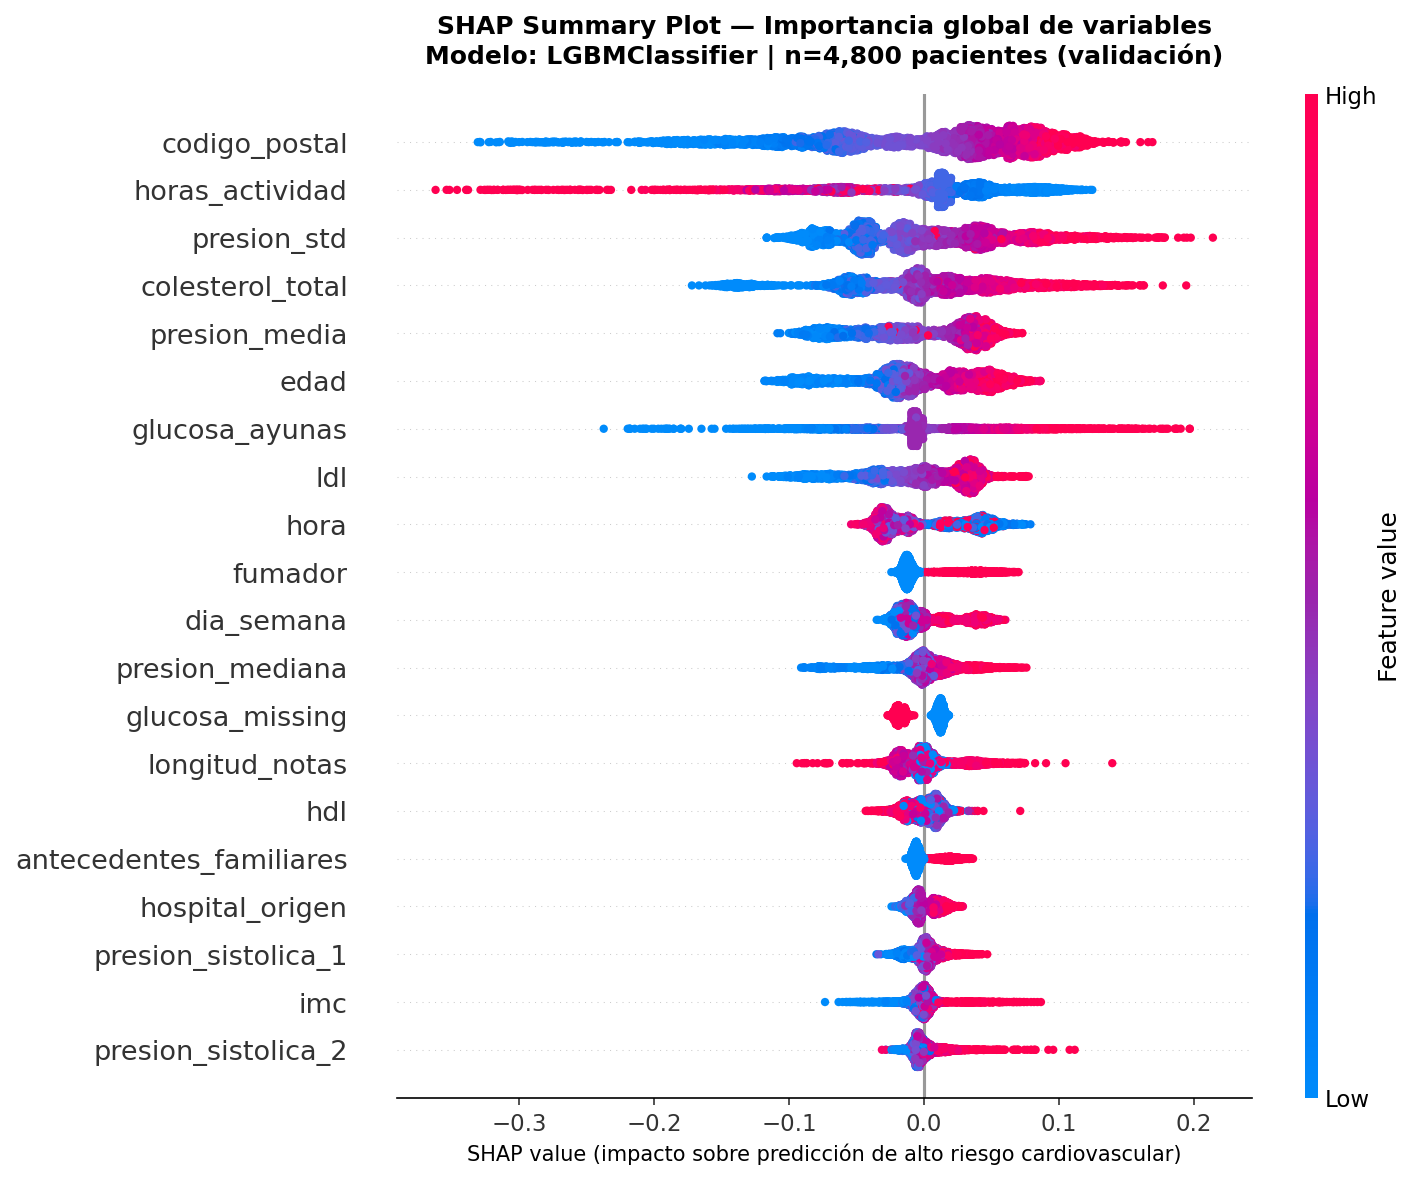

Figura exportada: figures/fig_shap_summary_beeswarm.png


In [11]:
# ── 3.4.4.A.1  Beeswarm summary plot (Top 20 variables) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_values_proba,
    X_val_proc,
    max_display=20,
    show=False,
    plot_size=None
)

plt.title(
    'SHAP Summary Plot — Importancia global de variables\n'
    f'Modelo: {model_name} | n={len(X_val_proc):,} pacientes (validación)',
    fontsize=12, fontweight='bold', pad=15
)
plt.xlabel('SHAP value (impacto sobre predicción de alto riesgo cardiovascular)', fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig_shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_summary_beeswarm.png")

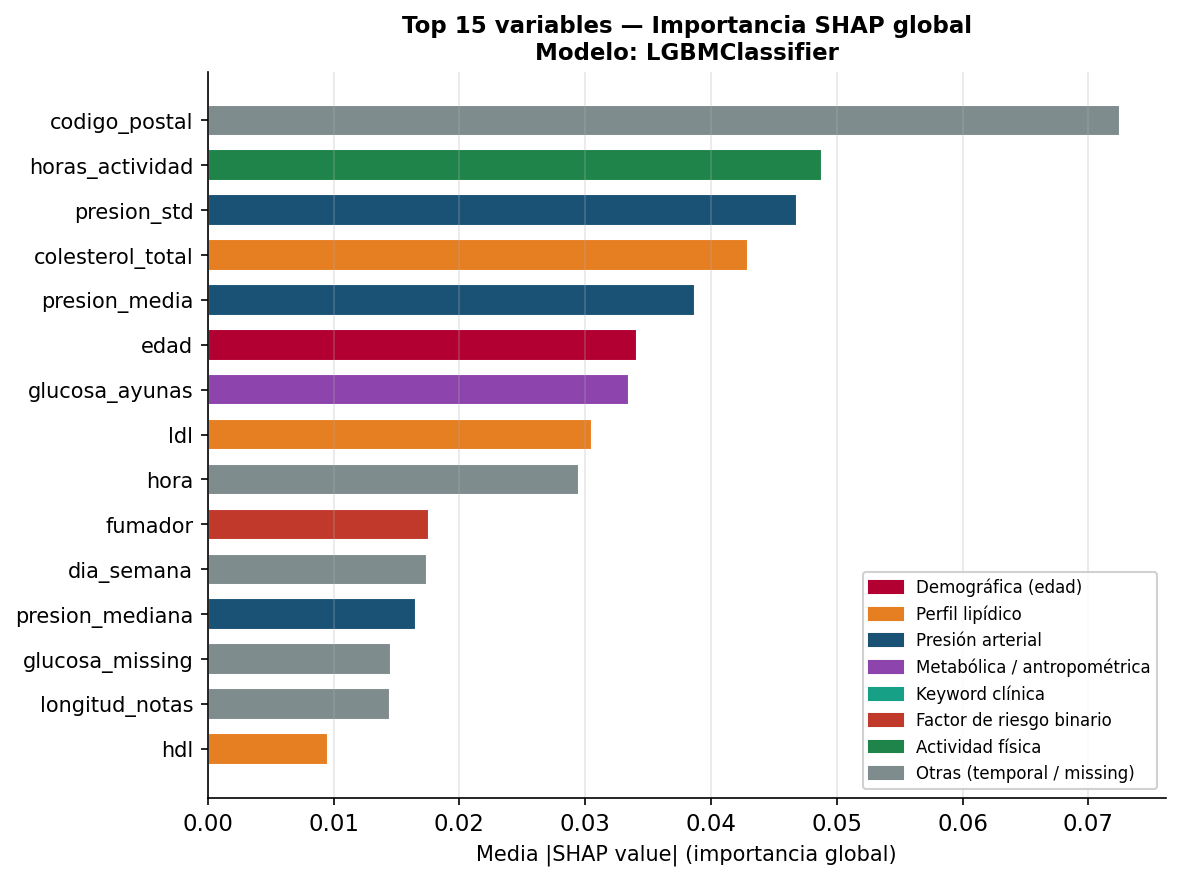

Figura exportada: figures/fig_shap_barplot_global.png


In [ ]:
# ── 3.4.4.A.2  Bar plot de importancia global ────────────
top_n = 15
top_feats = shap_importance.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))

# Colorear por categoría clínica
def categoria_clinica(nombre):
    if nombre in ['edad']:
        return CARDIS_RED
    if nombre in ['ldl', 'hdl', 'colesterol_total', 'ratio_ldl_hdl', 'ratio_colesterol_hdl']:
        return '#E67E22'
    if 'presion' in nombre:
        return CARDIS_BLUE
    if nombre in ['glucosa_ayunas', 'imc', 'peso_kg', 'altura_cm']:
        return '#8E44AD'
    if nombre.startswith('kw_'):
        return '#16A085'
    if nombre in ['fumador', 'antecedentes_familiares']:
        return '#C0392B'
    if nombre in ['horas_actividad']:
        return CARDIS_GREEN
    return '#7F8C8D'

colors = [categoria_clinica(f) for f in top_feats['feature']]

bars = ax.barh(range(top_n), top_feats['mean_abs_shap'].values,
               color=colors, edgecolor='white', height=0.7)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feats['feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Media |SHAP value| (importancia global)', fontsize=10)
ax.set_title(f'Top {top_n} variables — Importancia SHAP global\n'
             f'Modelo: {model_name}', fontsize=11, fontweight='bold')

# Leyenda de categorías
legend_items = [
    mpatches.Patch(color=CARDIS_RED,  label='Demográfica (edad)'),
    mpatches.Patch(color='#E67E22',   label='Perfil lipídico'),
    mpatches.Patch(color=CARDIS_BLUE, label='Presión arterial'),
    mpatches.Patch(color='#8E44AD',   label='Metabólica / antropométrica'),
    mpatches.Patch(color='#16A085',   label='Keyword clínica'),
    mpatches.Patch(color='#C0392B',   label='Factor de riesgo binario'),
    mpatches.Patch(color=CARDIS_GREEN,label='Actividad física'),
    mpatches.Patch(color='#7F8C8D',   label='Otras (temporal / missing)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_shap_barplot_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_barplot_global.png")

In [13]:
# ── 3.4.4.A.3  Análisis de coherencia clínica — tabla comparativa ─────────────
print("=" * 72)
print("COHERENCIA CLÍNICA DE LAS IMPORTANCIAS SHAP")
print("=" * 72)
print(f"{'Variable':<28} {'SHAP rank':>9} {'Evidencia clínica'}")
print("-" * 72)

evidencia = {
    'edad'              : 'Factor de riesgo no modificable #1 (Framingham, SCORE2)',
    'ldl'               : 'Colesterol LDL: factor modificable clave en Framingham',
    'presion_media'     : 'Hipertensión sistólica: variable central en SCORE2',
    'presion_sistolica_1': 'Medición directa de presión sistólica',
    'glucosa_ayunas'    : 'Diabetes/glucemia: factor de riesgo mayor en ECV',
    'colesterol_total'  : 'Incluido en todas las escalas CV (Framingham, SCORE2)',
    'imc'               : 'Obesidad: factor de riesgo indirecto reconocido',
    'horas_actividad'   : 'Actividad física: efecto protector establecido (OMS, 2020)',
    'kw_diabetes'       : 'Mención explícita de diabetes en nota clínica',
    'kw_infarto'        : 'Antecedente de infarto: factor de riesgo crítico',
    'fumador'           : 'Tabaquismo: incluido en SCORE2 y Framingham',
    'antecedentes_familiares': 'Historia familiar: factor de riesgo reconocido',
    'kw_angina'         : 'Angina de pecho: síntoma centinela de ECV',
    'hdl'               : 'HDL: factor protector (correlación inversa con riesgo)',
    'presion_std'       : 'Variabilidad de presión: indicador de riesgo independiente',
}

for rank, row in enumerate(shap_importance.head(15).itertuples(), 1):
    ev = evidencia.get(row.feature, 'Variable derivada del pipeline CARDIS')
    print(f"  {rank:>2}. {row.feature:<24} {row.mean_abs_shap:>7.4f}   {ev}")

print("-" * 72)
print("→ Las variables de mayor importancia SHAP son coherentes con la literatura")
print("  cardiovascular, lo que valida la capacidad explicativa del modelo.")

COHERENCIA CLÍNICA DE LAS IMPORTANCIAS SHAP
Variable                     SHAP rank Evidencia clínica
------------------------------------------------------------------------
   1. codigo_postal             0.0725   Variable derivada del pipeline CARDIS
   2. horas_actividad           0.0488   Actividad física: efecto protector establecido (OMS, 2020)
   3. presion_std               0.0469   Variabilidad de presión: indicador de riesgo independiente
   4. colesterol_total          0.0430   Incluido en todas las escalas CV (Framingham, SCORE2)
   5. presion_media             0.0387   Hipertensión sistólica: variable central en SCORE2
   6. edad                      0.0341   Factor de riesgo no modificable #1 (Framingham, SCORE2)
   7. glucosa_ayunas            0.0335   Diabetes/glucemia: factor de riesgo mayor en ECV
   8. ldl                       0.0305   Colesterol LDL: factor modificable clave en Framingham
   9. hora                      0.0295   Variable derivada del pipeline CARDI

<a id="344b"></a>
### 3.4.4.B  Waterfall plots — Análisis de casos individuales

Los *waterfall plots* descomponen la predicción del modelo para un paciente concreto, mostrando
cómo cada variable empuja la predicción desde el valor base $E[f(X)]$ hasta la predicción final $f(\mathbf{x})$.
Se analizan tres casos representativos del escenario de uso de CARDIS:

- **Caso A**: Paciente joven (< 50 años) con predicción de alto riesgo → ¿qué factores compensan la juventud?
- **Caso B**: Paciente mayor (> 65 años) con predicción de bajo riesgo → ¿qué factores protectores dominan?
- **Caso C**: Caso límite (*borderline*, probabilidad ~0.5) → incertidumbre del modelo y factores determinantes.

In [14]:
# ── 3.4.4.B.1  Selección de los tres casos representativos ────────────────────
val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)

# Caso A: paciente joven (edad < 50) con predicción alta (proba > 0.70)
mask_A = (val_reset['edad'] < 50) & (y_val_proba > 0.70) & (y_val_reset == 1)
idx_A  = np.where(mask_A)[0]
if len(idx_A) == 0:  # fallback si no hay candidatos exactos
    mask_A = (val_reset['edad'] < 55) & (y_val_proba > 0.60) & (y_val_reset == 1)
    idx_A  = np.where(mask_A)[0]
caso_A = idx_A[0]

# Caso B: paciente mayor (edad > 65) con predicción baja (proba < 0.25)
mask_B = (val_reset['edad'] > 65) & (y_val_proba < 0.25) & (y_val_reset == 0)
idx_B  = np.where(mask_B)[0]
if len(idx_B) == 0:
    mask_B = (val_reset['edad'] > 60) & (y_val_proba < 0.30) & (y_val_reset == 0)
    idx_B  = np.where(mask_B)[0]
caso_B = idx_B[0]

# Caso C: caso límite (proba entre 0.45 y 0.55)
mask_C = (y_val_proba >= 0.44) & (y_val_proba <= 0.56)
idx_C  = np.where(mask_C)[0]
# Elegir el más cercano a 0.50
caso_C = idx_C[np.argmin(np.abs(y_val_proba[idx_C] - 0.50))]

print("Casos seleccionados para waterfall plots:")
for nombre, idx in [('A — Joven, alto riesgo', caso_A),
                     ('B — Mayor, bajo riesgo', caso_B),
                     ('C — Caso límite',         caso_C)]:
    edad     = val_reset.loc[idx, 'edad']
    proba    = y_val_proba[idx]
    real     = y_val_reset.iloc[idx]
    print(f"  Caso {nombre}: idx={idx} | edad={edad:.0f} | P(alto riesgo)={proba:.3f} | real={real}")

Casos seleccionados para waterfall plots:
  Caso A — Joven, alto riesgo: idx=186 | edad=38 | P(alto riesgo)=0.946 | real=1
  Caso B — Mayor, bajo riesgo: idx=12 | edad=72 | P(alto riesgo)=0.004 | real=0
  Caso C — Caso límite: idx=3985 | edad=74 | P(alto riesgo)=0.500 | real=0


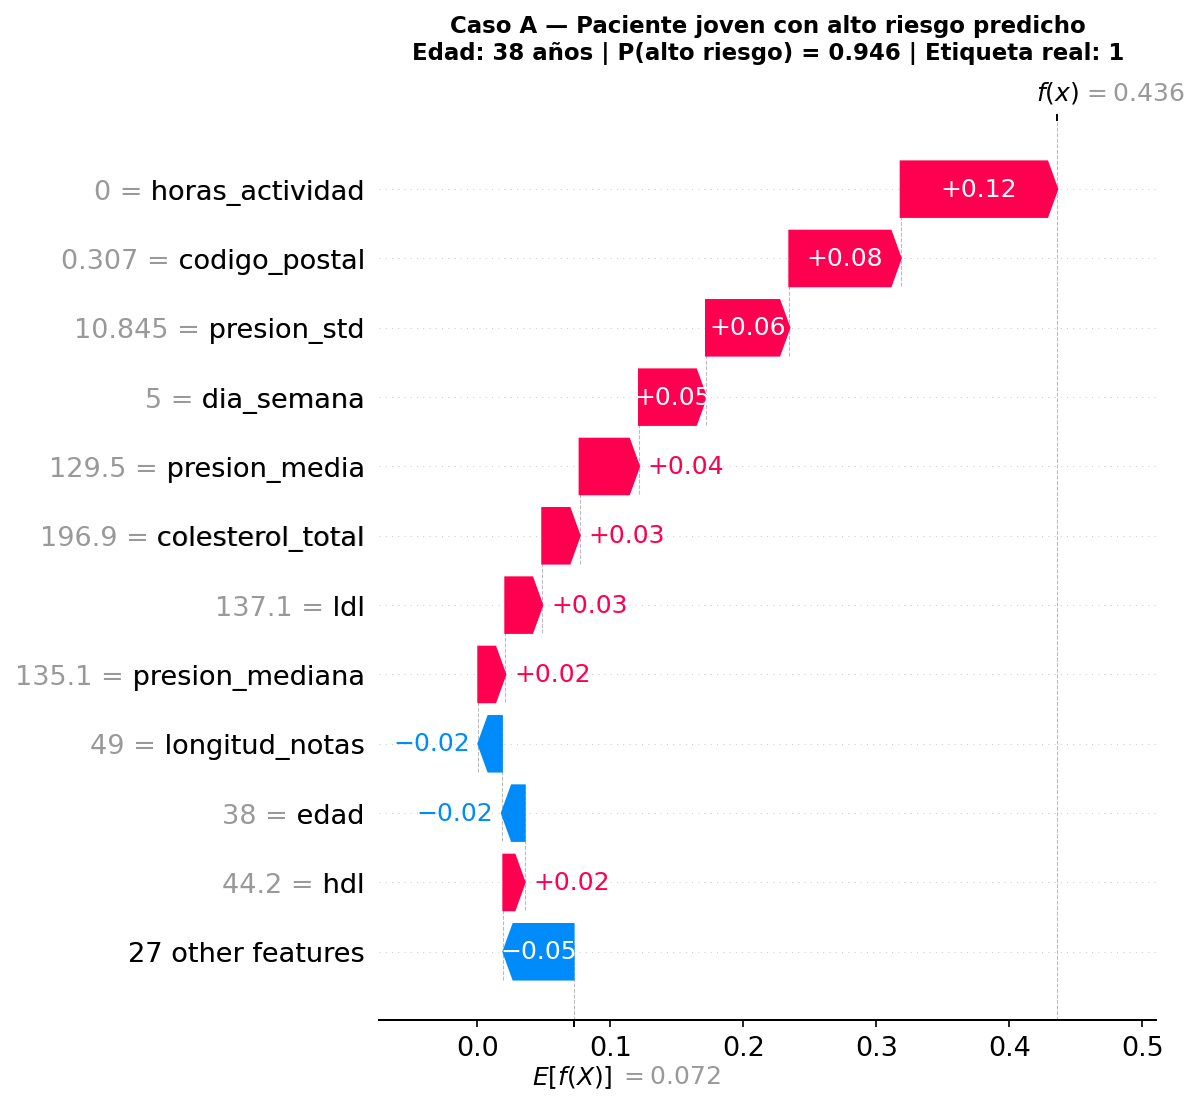

Figura exportada: figures/fig_shap_waterfall_casoA.png

Factores que AUMENTAN el riesgo (Caso A, edad=38):
  horas_actividad             : SHAP=+0.1177  (valor=0.000)
  codigo_postal               : SHAP=+0.0837  (valor=0.307)
  presion_std                 : SHAP=+0.0626  (valor=10.845)
  dia_semana                  : SHAP=+0.0504  (valor=5.000)
  presion_media               : SHAP=+0.0446  (valor=129.500)

Factores que REDUCEN el riesgo (Caso A, edad=38):
  longitud_notas              : SHAP=-0.0177  (valor=49.000)
  edad                        : SHAP=-0.0171  (valor=38.000)
  glucosa_missing             : SHAP=-0.0141  (valor=1.000)
  hospital_origen             : SHAP=-0.0110  (valor=0.201)
  hora                        : SHAP=-0.0093  (valor=10.000)


In [15]:
# ── 3.4.4.B.2  Waterfall plot — Caso A: paciente joven con alto riesgo ─────────
edad_A  = val_reset.loc[caso_A, 'edad']
proba_A = y_val_proba[caso_A]
real_A  = y_val_reset.iloc[caso_A]

fig, ax = plt.subplots(figsize=(9, 6))
shap.waterfall_plot(
    explanation[caso_A],
    max_display=12,
    show=False
)
plt.title(
    f'Caso A — Paciente joven con alto riesgo predicho\n'
    f'Edad: {edad_A:.0f} años | P(alto riesgo) = {proba_A:.3f} | Etiqueta real: {int(real_A)}',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig('figures/fig_shap_waterfall_casoA.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_waterfall_casoA.png")

# Análisis de los factores determinantes del Caso A
shap_A     = shap_values_proba[caso_A]
top_pos_A  = pd.Series(shap_A, index=X_val_proc.columns).nlargest(5)
top_neg_A  = pd.Series(shap_A, index=X_val_proc.columns).nsmallest(5)
print(f"\nFactores que AUMENTAN el riesgo (Caso A, edad={edad_A:.0f}):")
for feat, val in top_pos_A.items():
    feat_val = X_val_proc.iloc[caso_A][feat]
    print(f"  {feat:<28}: SHAP={val:+.4f}  (valor={feat_val:.3f})")
print(f"\nFactores que REDUCEN el riesgo (Caso A, edad={edad_A:.0f}):")
for feat, val in top_neg_A.items():
    feat_val = X_val_proc.iloc[caso_A][feat]
    print(f"  {feat:<28}: SHAP={val:+.4f}  (valor={feat_val:.3f})")

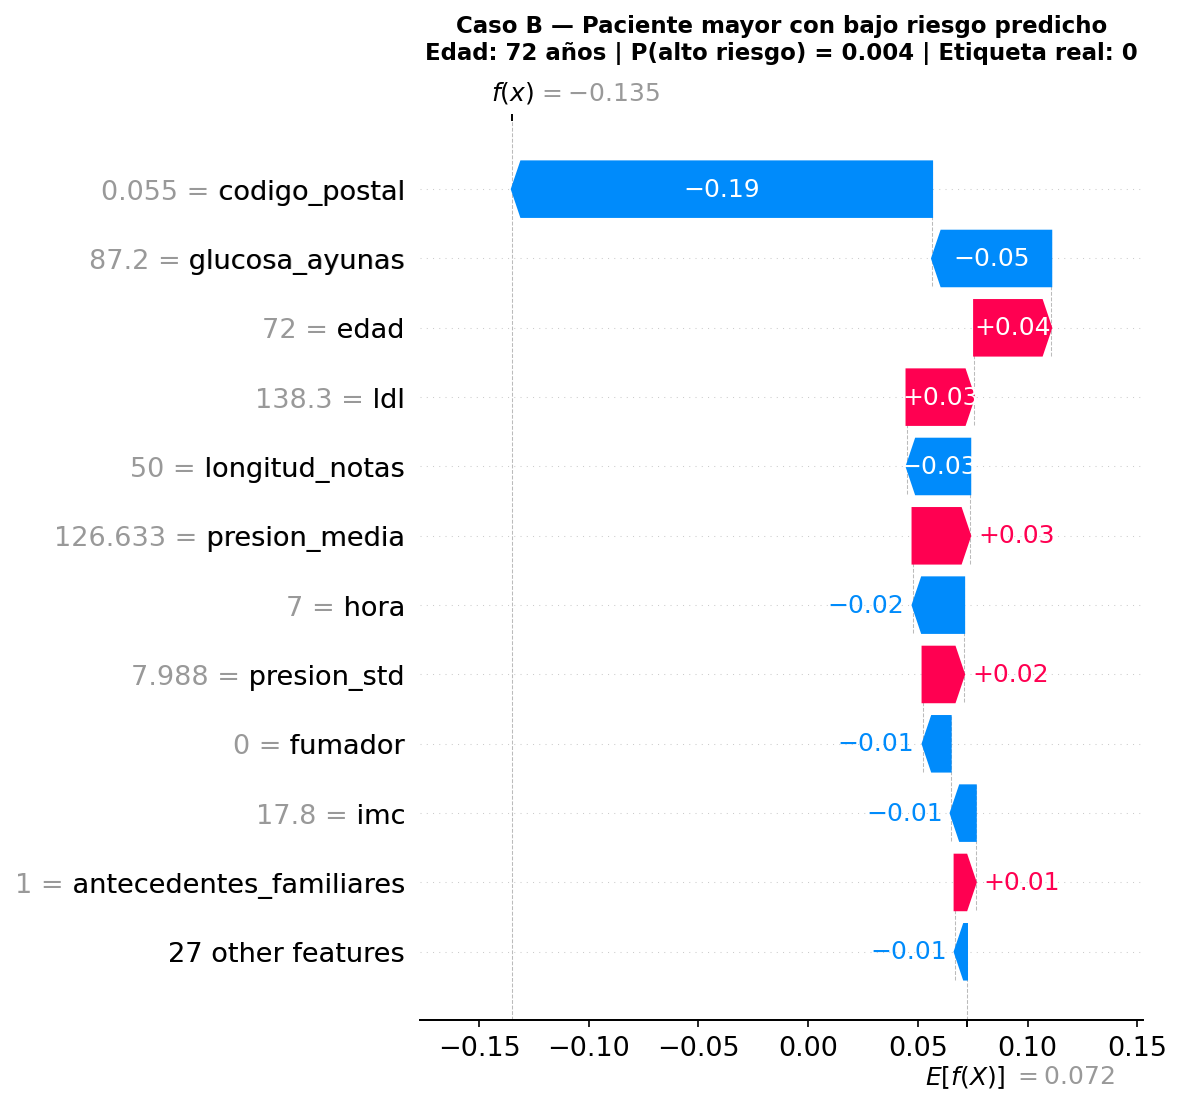

Figura exportada: figures/fig_shap_waterfall_casoB.png

Factores protectores dominantes (Caso B, edad=72):
  codigo_postal               : SHAP=-0.1915  (valor=0.055)
  glucosa_ayunas              : SHAP=-0.0543  (valor=87.200)
  longitud_notas              : SHAP=-0.0290  (valor=50.000)
  hora                        : SHAP=-0.0235  (valor=7.000)
  fumador                     : SHAP=-0.0128  (valor=0.000)


In [16]:
# ── 3.4.4.B.3  Waterfall plot — Caso B: paciente mayor con bajo riesgo ─────────
edad_B  = val_reset.loc[caso_B, 'edad']
proba_B = y_val_proba[caso_B]
real_B  = y_val_reset.iloc[caso_B]

fig, ax = plt.subplots(figsize=(9, 6))
shap.waterfall_plot(
    explanation[caso_B],
    max_display=12,
    show=False
)
plt.title(
    f'Caso B — Paciente mayor con bajo riesgo predicho\n'
    f'Edad: {edad_B:.0f} años | P(alto riesgo) = {proba_B:.3f} | Etiqueta real: {int(real_B)}',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig('figures/fig_shap_waterfall_casoB.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_waterfall_casoB.png")

# Análisis de los factores determinantes del Caso B
shap_B    = shap_values_proba[caso_B]
top_neg_B = pd.Series(shap_B, index=X_val_proc.columns).nsmallest(5)
print(f"\nFactores protectores dominantes (Caso B, edad={edad_B:.0f}):")
for feat, val in top_neg_B.items():
    feat_val = X_val_proc.iloc[caso_B][feat]
    print(f"  {feat:<28}: SHAP={val:+.4f}  (valor={feat_val:.3f})")

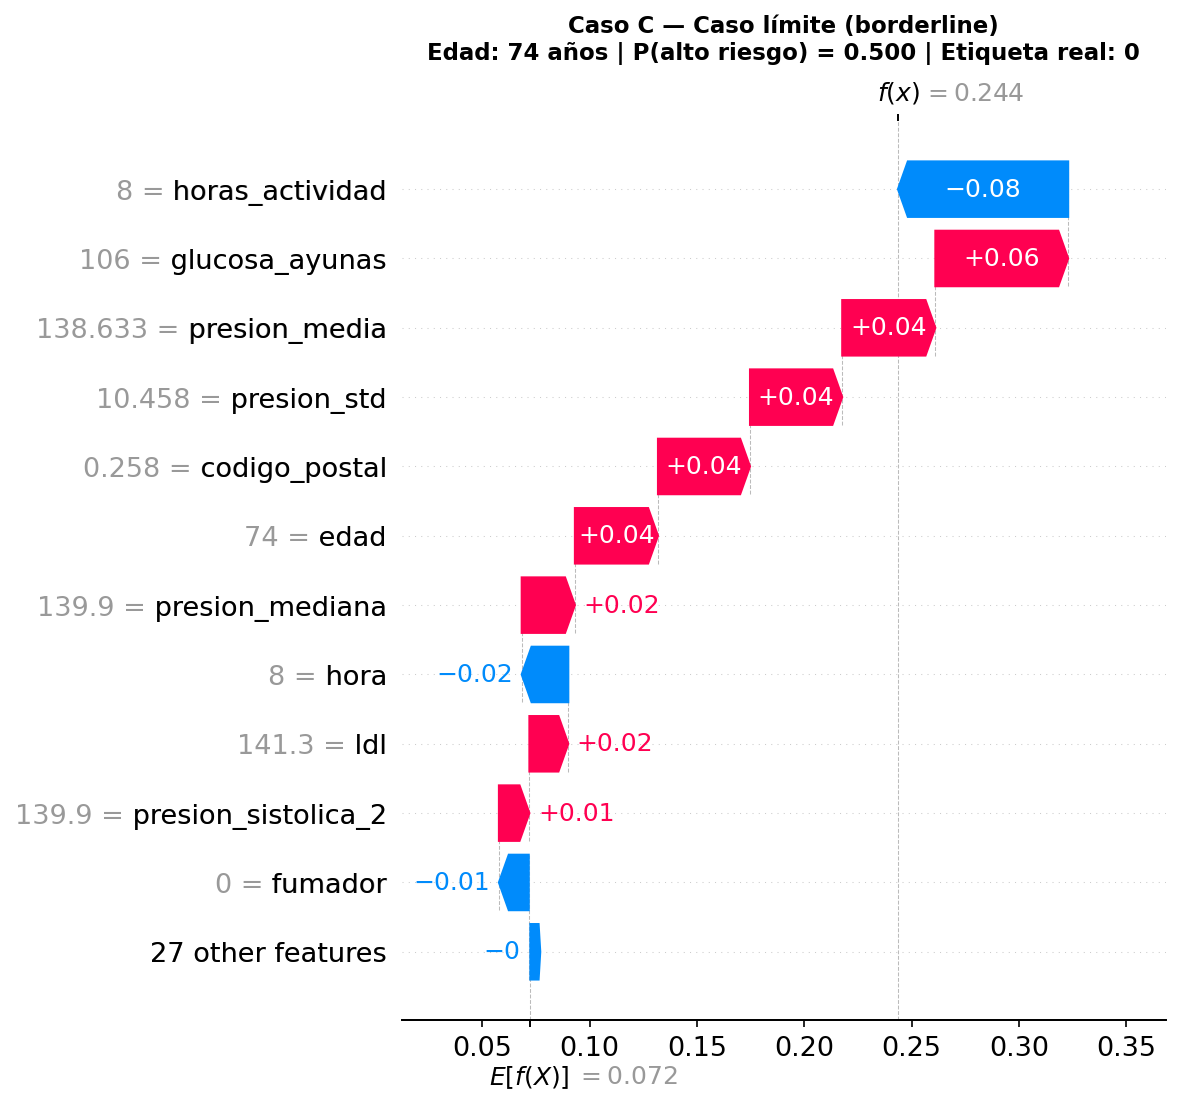

Figura exportada: figures/fig_shap_waterfall_casoC.png

Equilibrio de fuerzas (Caso C, P=0.500):
  Suma contribuciones positivas (riesgo+) : +0.3309
  Suma contribuciones negativas (riesgo-) : -0.1596
  Diferencia neta                         : +0.1713
→ En casos borderline, CARDIS informa explícitamente al médico de la incertidumbre.


In [17]:
# ── 3.4.4.B.4  Waterfall plot — Caso C: caso límite (borderline) ───────────────
edad_C  = val_reset.loc[caso_C, 'edad']
proba_C = y_val_proba[caso_C]
real_C  = y_val_reset.iloc[caso_C]

fig, ax = plt.subplots(figsize=(9, 6))
shap.waterfall_plot(
    explanation[caso_C],
    max_display=12,
    show=False
)
plt.title(
    f'Caso C — Caso límite (borderline)\n'
    f'Edad: {edad_C:.0f} años | P(alto riesgo) = {proba_C:.3f} | Etiqueta real: {int(real_C)}',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig('figures/fig_shap_waterfall_casoC.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_waterfall_casoC.png")

# Análisis del equilibrio de fuerzas en el Caso C
shap_C     = shap_values_proba[caso_C]
contrib_C  = pd.Series(shap_C, index=X_val_proc.columns)
suma_pos   = contrib_C[contrib_C > 0].sum()
suma_neg   = contrib_C[contrib_C < 0].sum()
print(f"\nEquilibrio de fuerzas (Caso C, P={proba_C:.3f}):")
print(f"  Suma contribuciones positivas (riesgo+) : {suma_pos:+.4f}")
print(f"  Suma contribuciones negativas (riesgo-) : {suma_neg:+.4f}")
print(f"  Diferencia neta                         : {suma_pos + suma_neg:+.4f}")
print("→ En casos borderline, CARDIS informa explícitamente al médico de la incertidumbre.")

In [18]:
# ── 3.4.4.B.5  Resumen clínico de los tres casos (para memoria) ───────────────
print("=" * 72)
print("RESUMEN CLÍNICO DE LOS TRES CASOS ANALIZADOS")
print("=" * 72)

resumen_casos = pd.DataFrame([
    {
        'Caso'       : 'A — Joven / Alto riesgo',
        'Edad'       : f"{val_reset.loc[caso_A, 'edad']:.0f}",
        'P(riesgo)'  : f"{y_val_proba[caso_A]:.3f}",
        'Real'       : int(y_val_reset.iloc[caso_A]),
        'Factor dominante': shap_values_proba[caso_A].argmax(),
        'Interpretación': 'Factores de riesgo modificables compensan la juventud'
    },
    {
        'Caso'       : 'B — Mayor / Bajo riesgo',
        'Edad'       : f"{val_reset.loc[caso_B, 'edad']:.0f}",
        'P(riesgo)'  : f"{y_val_proba[caso_B]:.3f}",
        'Real'       : int(y_val_reset.iloc[caso_B]),
        'Factor dominante': shap_values_proba[caso_B].argmin(),
        'Interpretación': 'Factores protectores (actividad, lípidos) compensan la edad'
    },
    {
        'Caso'       : 'C — Borderline',
        'Edad'       : f"{val_reset.loc[caso_C, 'edad']:.0f}",
        'P(riesgo)'  : f"{y_val_proba[caso_C]:.3f}",
        'Real'       : int(y_val_reset.iloc[caso_C]),
        'Factor dominante': '(equilibrio)',
        'Interpretación': 'Incertidumbre real; caso para revisión médica detallada'
    },
])
print(resumen_casos.to_string(index=False))

RESUMEN CLÍNICO DE LOS TRES CASOS ANALIZADOS
                   Caso Edad P(riesgo)  Real Factor dominante                                              Interpretación
A — Joven / Alto riesgo   38     0.946     1               23       Factores de riesgo modificables compensan la juventud
B — Mayor / Bajo riesgo   72     0.004     0               13 Factores protectores (actividad, lípidos) compensan la edad
         C — Borderline   74     0.500     0     (equilibrio)     Incertidumbre real; caso para revisión médica detallada


<a id="344c"></a>
### 3.4.4.C  Dependence plots — Relaciones no lineales

Los *dependence plots* muestran, para una variable de interés, cómo varía su SHAP value
a lo largo de todo su rango de valores. A diferencia de los coeficientes de regresión lineal,
estos gráficos capturan relaciones no lineales y puntos de inflexión clínicamente relevantes.
El color de cada punto indica el valor de la segunda variable de mayor interacción detectada automáticamente.

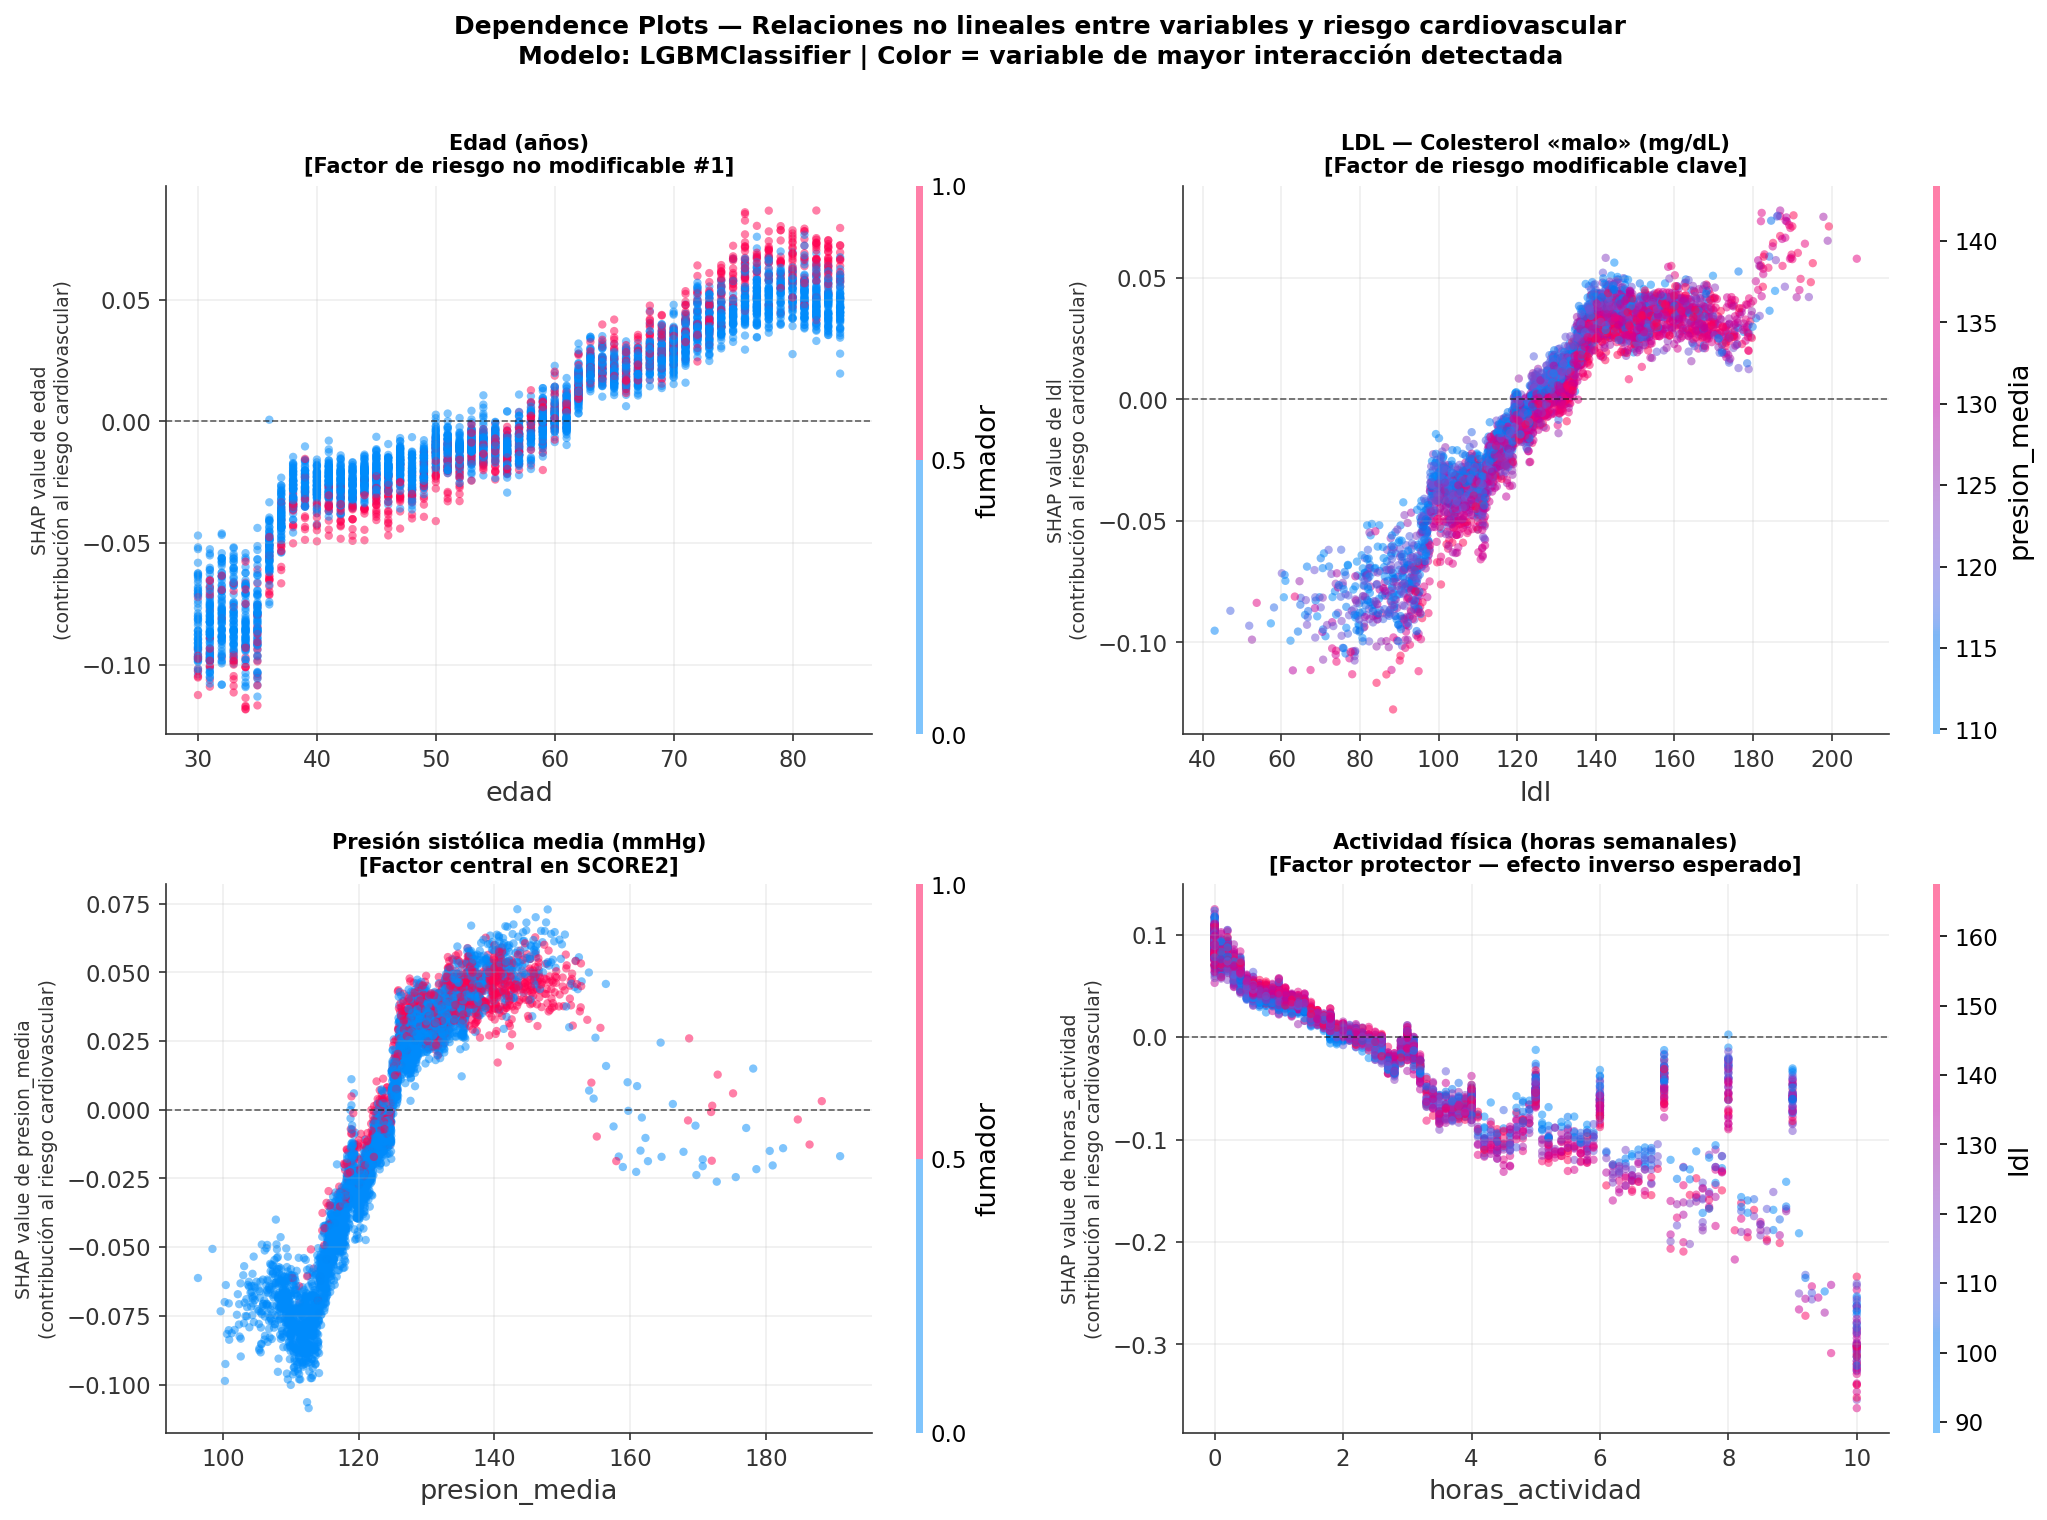

Figura exportada: figures/fig_shap_dependence_plots.png


In [19]:
# ── 3.4.4.C.1  Dependence plots para las 4 variables clínicas clave ───────────
# Variables seleccionadas por su relevancia clínica y presencia en escalas de referencia:
# edad, ldl, presion_media, horas_actividad

variables_dep = ['edad', 'ldl', 'presion_media', 'horas_actividad']
titulos_dep = [
    'Edad (años)\n[Factor de riesgo no modificable #1]',
    'LDL — Colesterol «malo» (mg/dL)\n[Factor de riesgo modificable clave]',
    'Presión sistólica media (mmHg)\n[Factor central en SCORE2]',
    'Actividad física (horas semanales)\n[Factor protector — efecto inverso esperado]',
]

# Filtrar variables que existen en el dataset transformado
variables_dep = [v for v in variables_dep if v in X_val_proc.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, (var, titulo) in enumerate(zip(variables_dep, titulos_dep)):
    ax = axes_flat[i]
    shap.dependence_plot(
        var,
        shap_values_proba,
        X_val_proc,
        ax=ax,
        show=False,
        alpha=0.5,
    )
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel(f'SHAP value de {var}\n(contribución al riesgo cardiovascular)', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    f'Dependence Plots — Relaciones no lineales entre variables y riesgo cardiovascular\n'
    f'Modelo: {model_name} | Color = variable de mayor interacción detectada',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('figures/fig_shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_dependence_plots.png")

In [20]:
# ── 3.4.4.C.2  Análisis de puntos de inflexión clínicos ──────────────────────
print("=" * 72)
print("ANÁLISIS DE PUNTOS DE INFLEXIÓN — VARIABLES CLAVE")
print("=" * 72)

for var in variables_dep:
    if var not in X_val_proc.columns:
        continue
    valores   = X_val_proc[var].values
    shap_var  = shap_values_proba[:, X_val_proc.columns.get_loc(var)]

    # Calcular SHAP medio por decil
    deciles = np.percentile(valores[~np.isnan(valores)], np.arange(10, 100, 10))
    shap_medios = []
    for d_low, d_high in zip([valores.min()] + list(deciles),
                               list(deciles) + [valores.max()]):
        mask = (valores >= d_low) & (valores <= d_high)
        shap_medios.append(shap_var[mask].mean() if mask.sum() > 0 else np.nan)

    # Detectar dónde cruza el cero (punto de inflexión)
    cambio_signo = None
    for j in range(len(shap_medios) - 1):
        if not (np.isnan(shap_medios[j]) or np.isnan(shap_medios[j+1])):
            if shap_medios[j] * shap_medios[j+1] < 0:
                cambio_signo = (deciles[j-1] if j > 0 else valores.min(),
                                deciles[j] if j < len(deciles) else valores.max())
                break

    dir_efecto = '↑ riesgo' if shap_var.mean() > 0 else '↓ riesgo (protector)'
    print(f"\n  {var}:")
    print(f"    Rango observado   : [{valores.min():.1f}, {valores.max():.1f}]")
    print(f"    SHAP medio        : {shap_var.mean():+.4f}  ({dir_efecto})")
    print(f"    SHAP correlación  : {np.corrcoef(valores[~np.isnan(valores)], shap_var[~np.isnan(valores)])[0,1]:+.3f}")
    if cambio_signo:
        print(f"    Punto de inflexión: {cambio_signo[0]:.1f} – {cambio_signo[1]:.1f}  (zona de cambio de efecto)")

ANÁLISIS DE PUNTOS DE INFLEXIÓN — VARIABLES CLAVE

  edad:
    Rango observado   : [30.0, 84.0]
    SHAP medio        : -0.0018  (↓ riesgo (protector))
    SHAP correlación  : +0.951
    Punto de inflexión: 51.0 – 57.0  (zona de cambio de efecto)

  ldl:
    Rango observado   : [43.0, 206.4]
    SHAP medio        : -0.0031  (↓ riesgo (protector))
    SHAP correlación  : +0.924
    Punto de inflexión: 121.8 – 127.3  (zona de cambio de efecto)

  presion_media:
    Rango observado   : [96.3, 190.9]
    SHAP medio        : -0.0020  (↓ riesgo (protector))
    SHAP correlación  : +0.849
    Punto de inflexión: 122.4 – 125.3  (zona de cambio de efecto)

  horas_actividad:
    Rango observado   : [0.0, 10.0]
    SHAP medio        : +0.0010  (↑ riesgo)
    SHAP correlación  : -0.912
    Punto de inflexión: 1.8 – 2.5  (zona de cambio de efecto)


<a id="344d"></a>
### 3.4.4.D  Coherencia clínica global: síntesis interpretativa

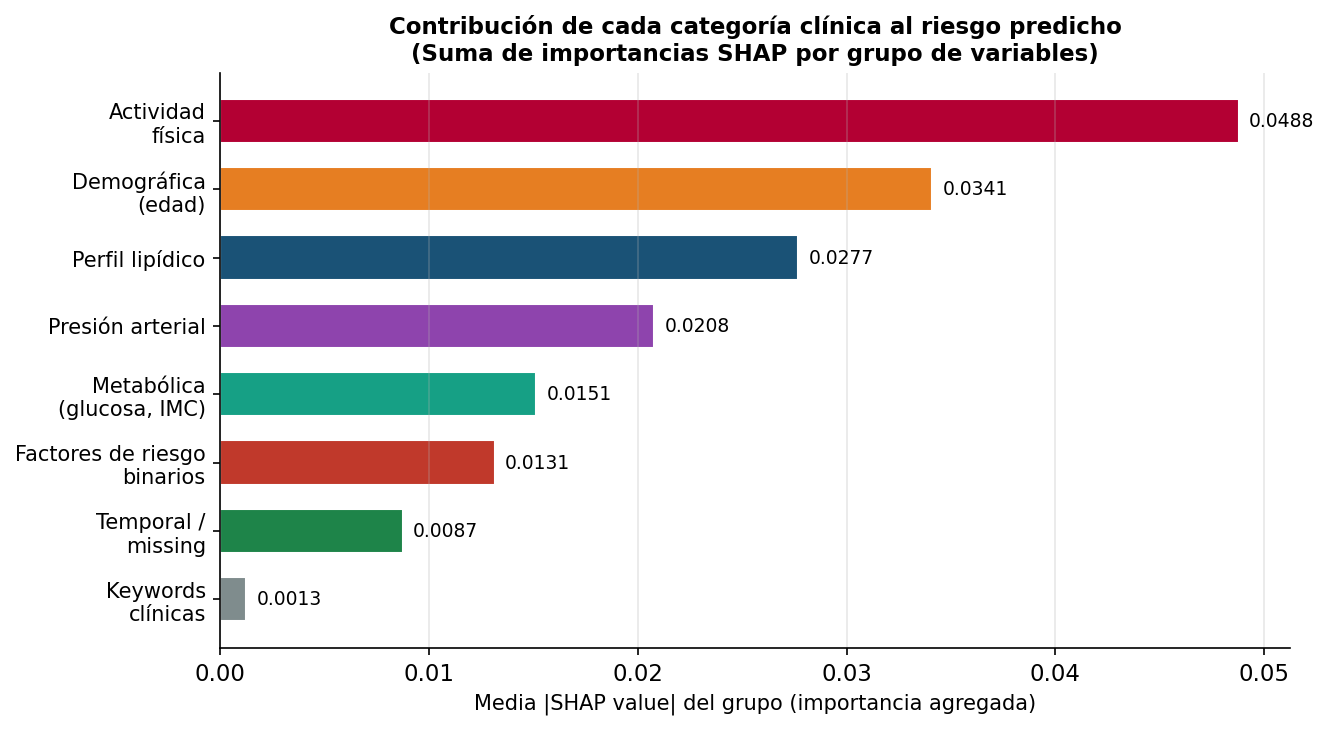

Figura exportada: figures/fig_shap_categorias_clinicas.png


In [21]:
# ── 3.4.4.D  Figura de síntesis: contribución media por categoría clínica ──────
# Agrupa variables por su categoría clínica y muestra la contribución total
# de cada grupo al riesgo predicho.

categorias = {
    'Demográfica\n(edad)'           : ['edad'],
    'Perfil lipídico'               : ['ldl', 'hdl', 'colesterol_total'],
    'Presión arterial'              : [c for c in X_val_proc.columns if 'presion' in c],
    'Metabólica\n(glucosa, IMC)'    : ['glucosa_ayunas', 'imc', 'peso_kg'],
    'Keywords\nclínicas'            : [c for c in X_val_proc.columns if c.startswith('kw_')],
    'Factores de riesgo\nbinarios'  : ['fumador', 'antecedentes_familiares'],
    'Actividad\nfísica'             : ['horas_actividad'],
    'Temporal /\nmissing'           : [c for c in X_val_proc.columns
                                       if c in ['anio', 'mes', 'dia_semana', 'hora', 'es_fin_semana',
                                                'glucosa_missing', 'notas_missing', 'actividad_missing']],
}

contrib_categoria = {}
for cat, feats in categorias.items():
    feats_ok = [f for f in feats if f in X_val_proc.columns]
    if feats_ok:
        idx_feats = [X_val_proc.columns.get_loc(f) for f in feats_ok]
        contrib_categoria[cat] = np.abs(shap_values_proba[:, idx_feats]).mean()

contrib_s = pd.Series(contrib_categoria).sort_values(ascending=True)
colors_cat = [CARDIS_RED, '#E67E22', CARDIS_BLUE, '#8E44AD',
              '#16A085', '#C0392B', CARDIS_GREEN, '#7F8C8D']
colors_cat = colors_cat[:len(contrib_s)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(contrib_s)), contrib_s.values,
               color=list(reversed(colors_cat)), edgecolor='white', height=0.65)
ax.set_yticks(range(len(contrib_s)))
ax.set_yticklabels(contrib_s.index, fontsize=10)
ax.set_xlabel('Media |SHAP value| del grupo (importancia agregada)', fontsize=10)
ax.set_title('Contribución de cada categoría clínica al riesgo predicho\n'
             '(Suma de importancias SHAP por grupo de variables)',
             fontsize=11, fontweight='bold')

# Etiquetas de valor
for bar, val in zip(bars, contrib_s.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_shap_categorias_clinicas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura exportada: figures/fig_shap_categorias_clinicas.png")